In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# notebook は EXP_v3/src/ にあるので parents[1] がプロジェクトルート
ROOT = Path().resolve().parents[1]
RESULTS_DIR = ROOT / "EXP_v3" / "results"
print(f"Project root: {ROOT}")
print(f"Results dir : {RESULTS_DIR}")

Project root: /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History
Results dir : /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP_v3/results


In [2]:
dqn_path = RESULTS_DIR / "summary_3pl_1_100items_DQN_normal_epsilon_0.1_gamma_0.5_research_param.csv"
mfi_path = RESULTS_DIR / "summary_3pl_1_100items_MFI_MLE_python.csv"

dqn = pd.read_csv(dqn_path)
mfi = pd.read_csv(mfi_path)

print(f"DQN: {dqn_path.name}")
display(dqn)
print(f"MFI: {mfi_path.name}")
display(mfi)

print(f"\nmean RMSE (steps 1-{len(dqn)}):")
print(f"  DQN : {dqn['RMSE'].mean():.4f}")
print(f"  MFI : {mfi['RMSE'].mean():.4f}")
print(f"step {int(dqn['step'].iloc[-1])} RMSE:")
print(f"  DQN : {dqn['RMSE'].iloc[-1]:.4f}")
print(f"  MFI : {mfi['RMSE'].iloc[-1]:.4f}")

DQN: summary_3pl_1_100items_DQN_normal_epsilon_0.1_gamma_0.5_research_param.csv


,step,Bias,RMSE,MAE
0,1.0,-0.137486,0.942540,0.753424
1,2.0,0.052508,0.805083,0.630801
2,3.0,0.032618,0.736443,0.576863
3,4.0,-0.004132,0.702806,0.543135
4,5.0,-0.065846,0.778910,0.559286
5,6.0,-0.126905,0.886301,0.598139
6,7.0,-0.081023,0.761982,0.532969
7,8.0,-0.057792,0.687443,0.488191
8,9.0,-0.045669,0.634757,0.458728
9,10.0,-0.066163,0.675959,0.469587


MFI: summary_3pl_1_100items_MFI_MLE_python.csv


,step,Bias,RMSE,MAE,r
0,1,0.054874,0.957957,0.769616,0.542650
1,2,0.068028,0.819239,0.643698,0.665583
2,3,0.001649,0.828291,0.626204,0.713177
3,4,-0.124412,0.967864,0.680691,0.726564
4,5,-0.066703,0.810116,0.584366,0.773105
5,6,-0.061685,0.764438,0.552548,0.794224
6,7,-0.051508,0.712339,0.518981,0.819663
7,8,-0.041372,0.658941,0.489472,0.841211
8,9,-0.035897,0.624889,0.462968,0.854049
9,10,-0.032285,0.598429,0.444241,0.864839



mean RMSE (steps 1-10):
  DQN : 0.7612
  MFI : 0.7743
step 10 RMSE:
  DQN : 0.6760
  MFI : 0.5984


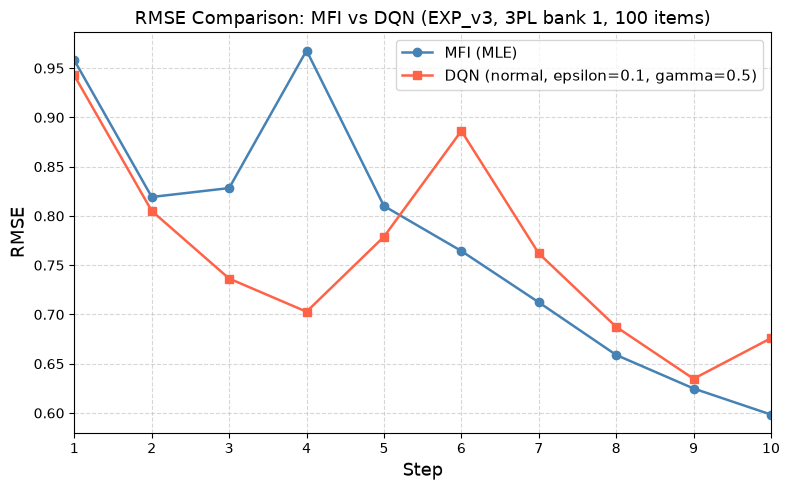

Saved to /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP_v3/results/rmse_comparison_3pl_1_100items_DQN_research_param_vs_MFI.png


In [3]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(mfi["step"], mfi["RMSE"], label="MFI (MLE)", color="steelblue", linewidth=1.8, marker="o")
ax.plot(dqn["step"], dqn["RMSE"], label="DQN (normal, epsilon=0.1, gamma=0.5)", color="tomato", linewidth=1.8, marker="s")

ax.set_xlabel("Step", fontsize=13)
ax.set_ylabel("RMSE", fontsize=13)
ax.set_title("RMSE Comparison: MFI vs DQN (EXP_v3, 3PL bank 1, 100 items)", fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, linestyle="--", alpha=0.5)
ax.set_xlim(1, max(dqn["step"].max(), mfi["step"].max()))

plt.tight_layout()

out_path = RESULTS_DIR / "rmse_comparison_3pl_1_100items_DQN_research_param_vs_MFI.png"
fig.savefig(out_path, dpi=150)
plt.show()
print(f"Saved to {out_path}")